# Chapter 6: The True Static Split (Train / Val / Test) & Hyperparameter Grid

This notebook implements the gold-standard Chronological Static Split (1500 days Train / 500 days Val / 500 days Test).
It loops through a grid of Neural Network configurations (architectures and learning rates). 
The model that achieves the lowest NLL on the Validation Set is selected as the winner. 
Finally, the winning NN and the Baseline are evaluated purely on the Out-Of-Sample Test Set.

In [34]:
import warnings
warnings.filterwarnings('ignore')

import sys

from datetime import date
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

from density_forecasting.evaluation.metrics import block_ks_test
from density_forecasting.evaluation.metrics import evaluate_forecasts, kupiec_pof_test
from density_forecasting.models.neural_networks import generate_montecarlo
from density_forecasting.models.tf_neural_networks import create_cnn_sequences

# Import our optimized pipeline functions
from density_forecasting.evaluation.fast_pipeline import (
    read_data_features,
    extract_array,
    extract_df_nn,
    run_baseline,
    backtesting_baseline,
    initializate_nn_model,
    run_neural_networks,
    backtesting_neural_networks
)

# import warnings
# warnings.filterwarnings('ignore')

# import sys
# sys.path.append('..')
# import os

# from datetime import date
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import t

# from src.evaluation.metrics import block_ks_test, evaluate_forecasts, kupiec_pof_test
# from src.models.neural_networks import generate_montecarlo

# # Import optimized pipeline functions
# from src.evaluation.fast_pipeline import (
#     read_data_features, extract_array, extract_df_nn, run_baseline,
#     backtesting_baseline, initializate_nn_model, run_neural_networks,
#     backtesting_neural_networks
# )


## 1. Configuration & Tuning Grid

In [35]:

# df_features.columns

In [36]:
# tickers = ['ARKK', 'USO', 'BTC-USD', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]
# tickers = ['ARKK', 'USO', 'SQM-B.SN', 'SPY', "TSLA", "DBK.DE"]
# tickers = ['QQQ',
#    ]


tickers = [
    'ARKK', 
    'USO', 
   #  'SQM-B.SN', 
    'SPY', 
    "TSLA", 
   #  "DBK.DE", 
    'QQQ',
   'XLF',
   # 'EEM',
   # 'ECH',
   # 'TLT',
   'NVDA'
   ]

# tickers = ['SPY']
# tickers = ['ARKK', 'USO', 'SQM-B.SN']


# tickers = ["SPY", "TSLA", "DBK.DE"]
# start_date = date(2010, 1, 1) # Earlier start date to get more data
start_date = date(2010, 4, 30) # Earlier start date to get more data
end_date = date(2026, 6, 1)

# columns_deep = ['vix_ratio', 'VIX']
columns_linear = ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
columns_deep = ['vix_ratio']




# 
# columns_deep = ['vix_ratio']

initial_epochs = 4001
MIN_DATA_ROWS = 2500 # 1500 Train, 500 Val, 500 Test = approx 10 years

# Hyperparameter Grid
# grid_columns_deep = [['vix_ratio'], ['vix_ratio', 'Feat_Volume_Shock'], ['vix_ratio', 'Feat_RSI_14'], ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14']]
grid_columns_linear = [
                  #   ['returns_m1', 
                  #    'returns_m1_2', 
                  #    # 'vix_ratio'
                  #   ]
                    ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt', 
                     'returns_m1_2',
                     'Macro_USD_Trend',
                     'Macro_Credit_Stress',
                     # 'Copper_Trend'
                     
                     ],
      #               'prices', 'volume', 'Macro_Rate_Shock', 'Macro_USD_Trend',
      #  'Macro_Credit_Stress', 'returns', 'returns_m1', 'returns_m2',
      #  'returns_m3', 'returns_m1_2', 'returns_m2_2', 'returns_m3_2',
      #  'Vol_50_MA', 'Feat_Volume_Shock', 'Feat_Momentum_20',
      #  'Feat_Realized_Vol_20', 'Feat_RSI_14', 'returns_m1_mean',
      #  'returns_m1_std', 'returns_m1_kurt', 'returns_m1_skew',
      #  'returns_m1_mean_st', 'returns_m1_std_st', 'returns_m1_nu', 'VIX',
      #  'vix_ratio'
                  #   ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt', 
                  #    'returns_m1_2',
                  #    'vix_ratio'
                  #    # 'returns_m2',
                  #    # 'returns_m3',
                  #    ], 
                     #   ['returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt'], 
                     #   ['Feat_Realized_Vol_20', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt'],
                     #   ['Feat_Realized_Vol_20', 'returns_m1', 'returns_m1_std_st', 'returns_m1_kurt'],
                     #   ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_kurt'],
                     #   ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st']
                       ]
# df_features['returns_m2'] = df_features['returns'].shift(2)
#     df_features['returns_m3'] = df_features['returns'].shift(3)

#     df_features['returns_m1_2'] = df_features['returns_m1_2']**2
#     df_features['returns_m2_2'] = df_features['returns_m2_2']**2
#     df_features['returns_m3_2'] = df_features['returns_m3_2']**2

grid_columns_deep = [
                  # ['vix_ratio',
                  #    #  'returns_m1_2',
                  #    # 'returns_m2_2',
                  #    # 'returns_m3_2'
                  #    ],
                     # ['vix_ratio', 'Feat_Volume_Shock', 'returns_m1_2',],
                     ['vix_ratio', 'Macro_Rate_Shock'],
                     # ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14'],


                     ]

# grid_columns_linear = [
#                        ['returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
#                        ]

# grid_model_classes = ['Linear', 'WideAndDeep']
grid_model_classes = ['WideAndDeep']
grid_lrs = [0.015]
# grid_lrs = [0.015, 0.005]
# grid_lambda_regs = [0.5, 0.6]
grid_lambda_regs = [0.5, 1.0, 2.0]
# grid_lambda_regs = [0.01, 0.05, 0.1, 0.5]




In [37]:
# print(len(baseline_prior_v['mu'][20:]), len(baseline_prior_v['mu'][:]))



STATIC SPLIT SHOWDOWN & TUNING: ARKK
Fetching ARKK data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 1775 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.5055, ks_stat: 0.0551
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.5044, ks_stat: 0.0337
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st

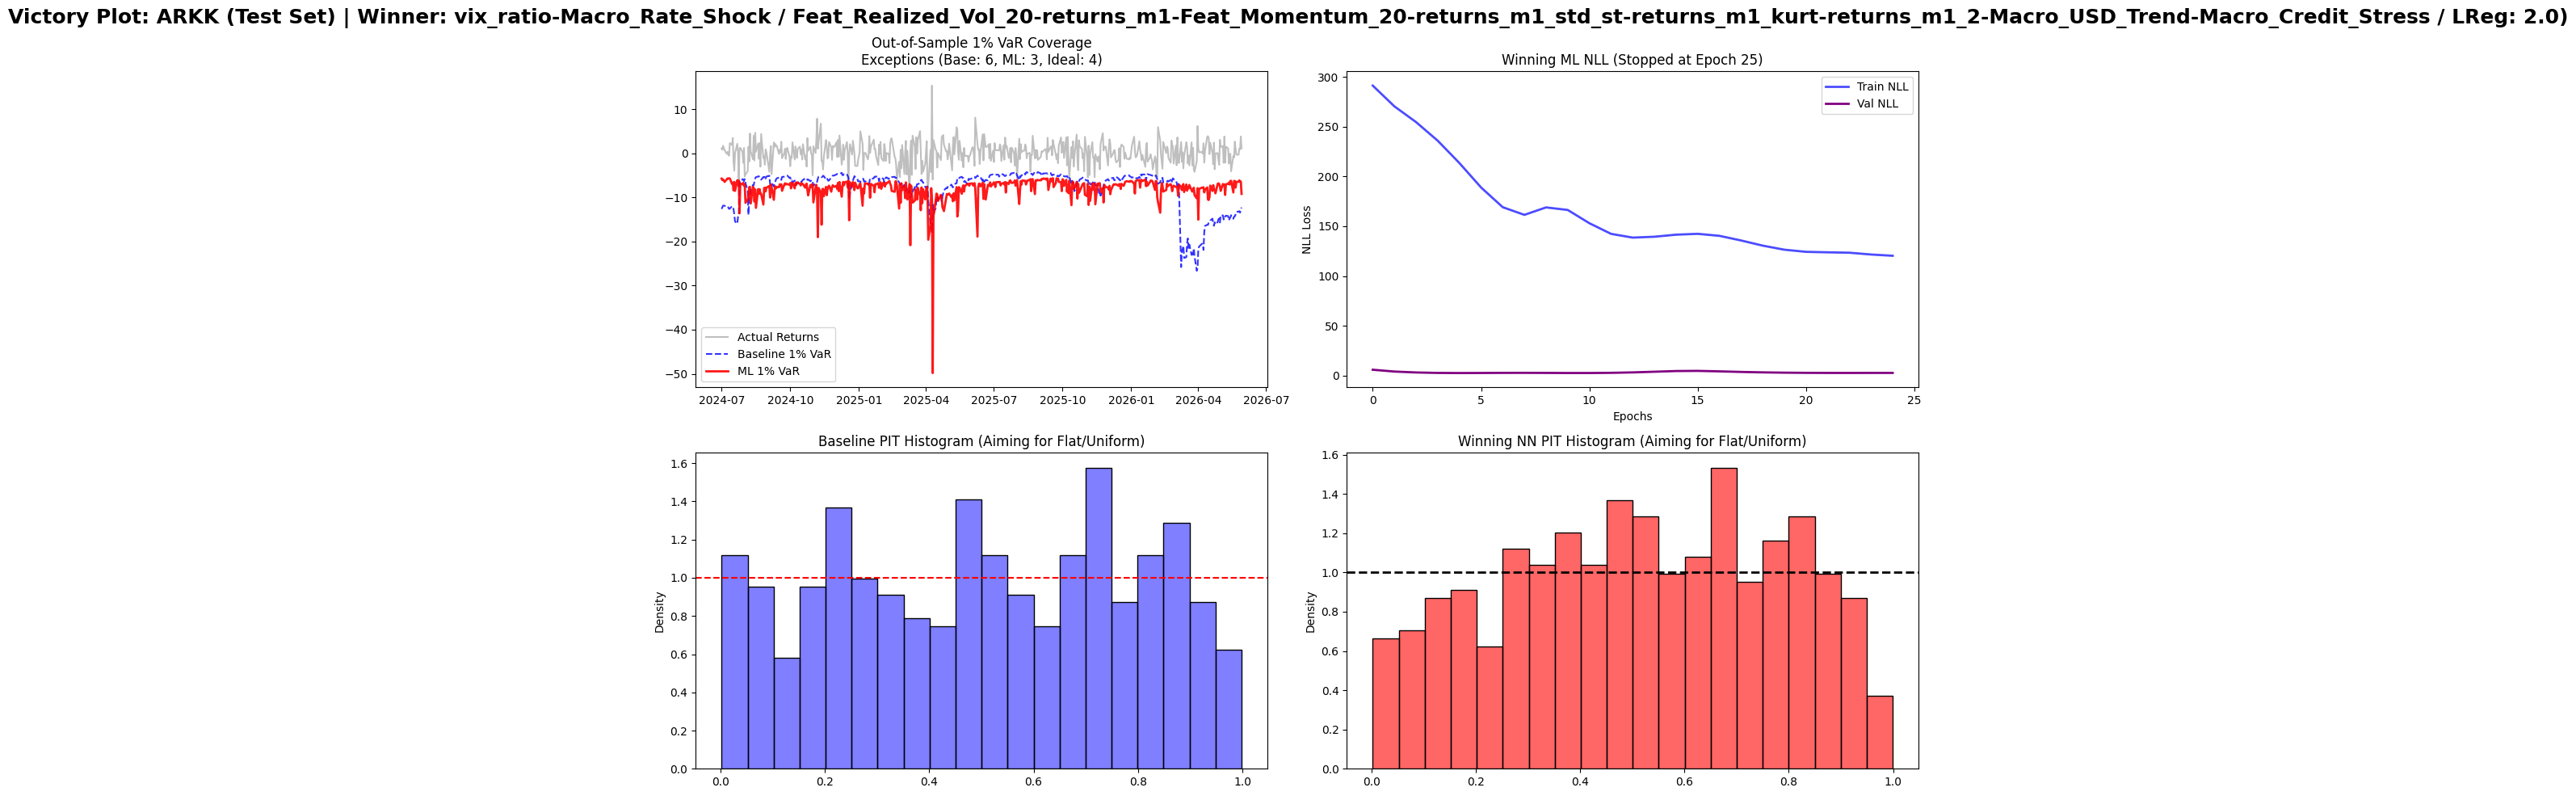


STATIC SPLIT SHOWDOWN & TUNING: USO
Fetching USO data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2910 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.1537, ks_stat: 0.0746
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.1303, ks_stat: 0.0390
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_

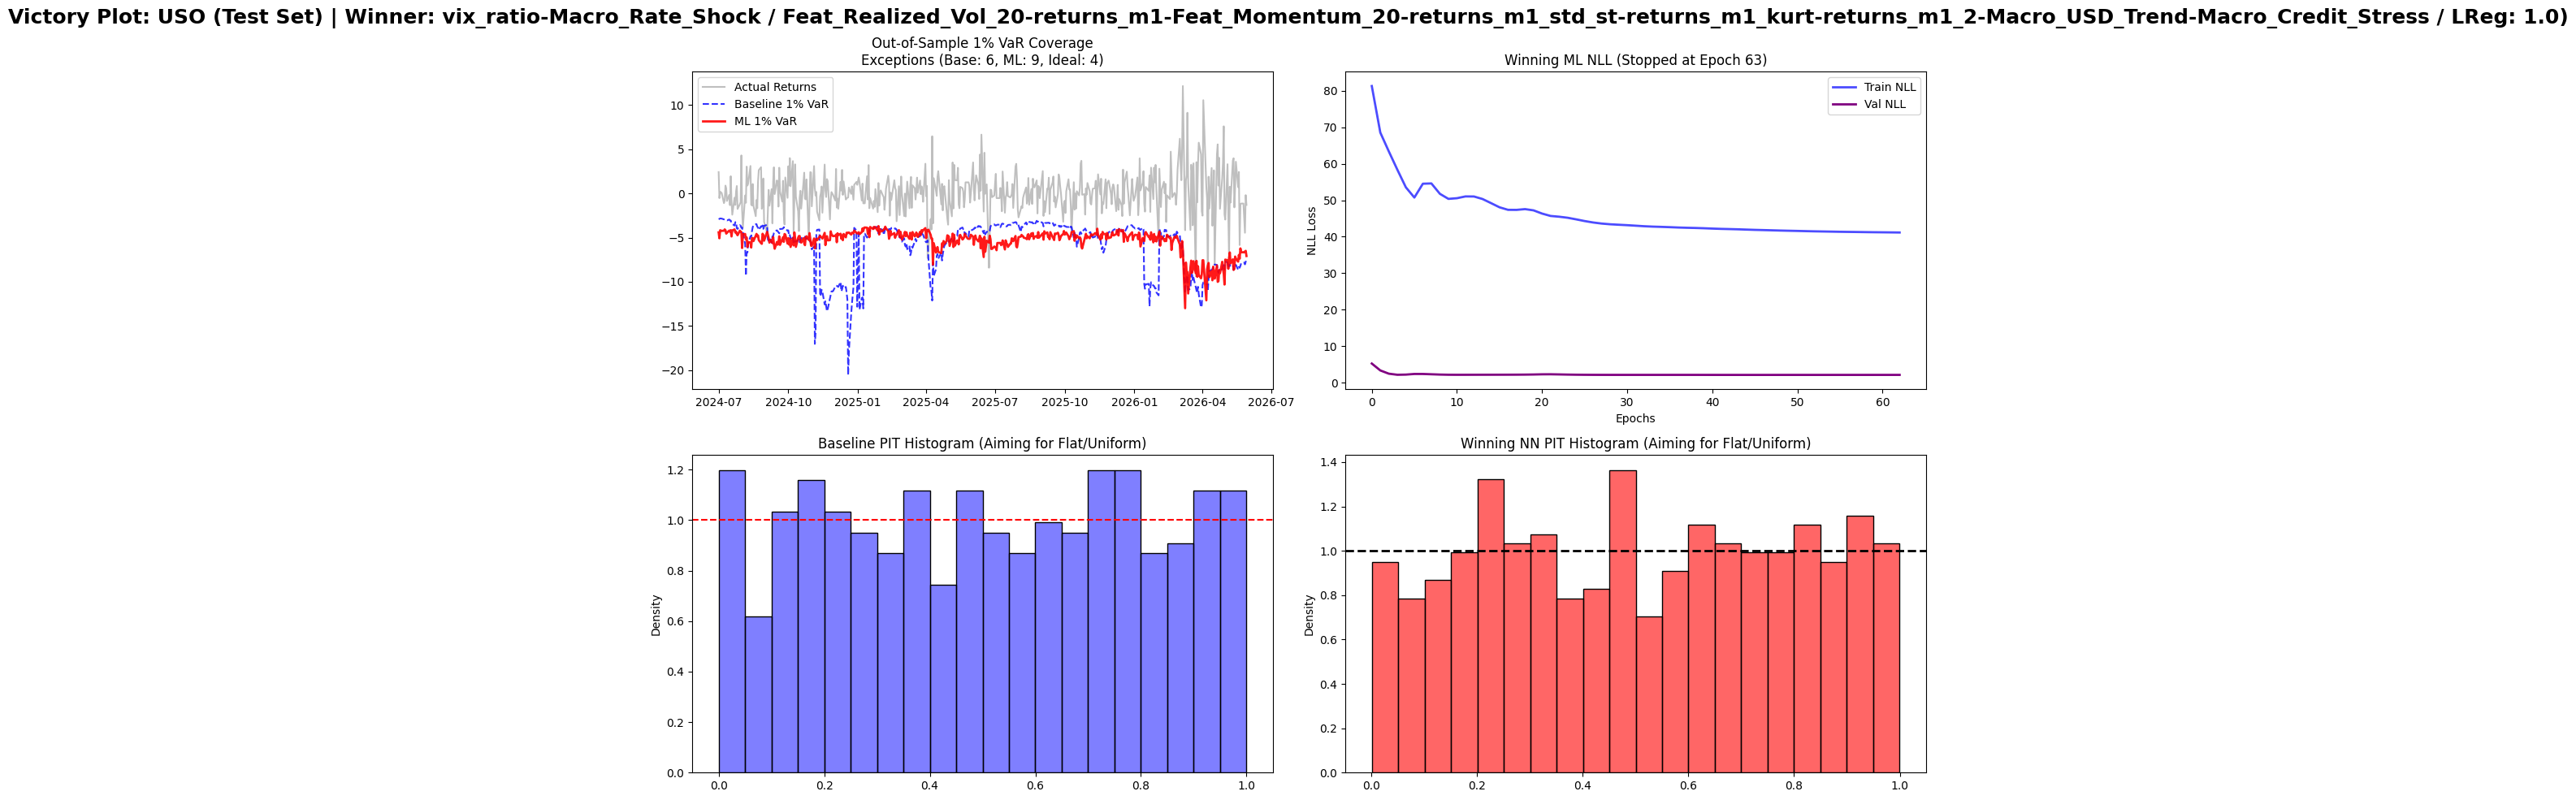


STATIC SPLIT SHOWDOWN & TUNING: SPY
Fetching SPY data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2910 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.4346, ks_stat: 0.0655
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 1.4175, ks_stat: 0.0318
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_

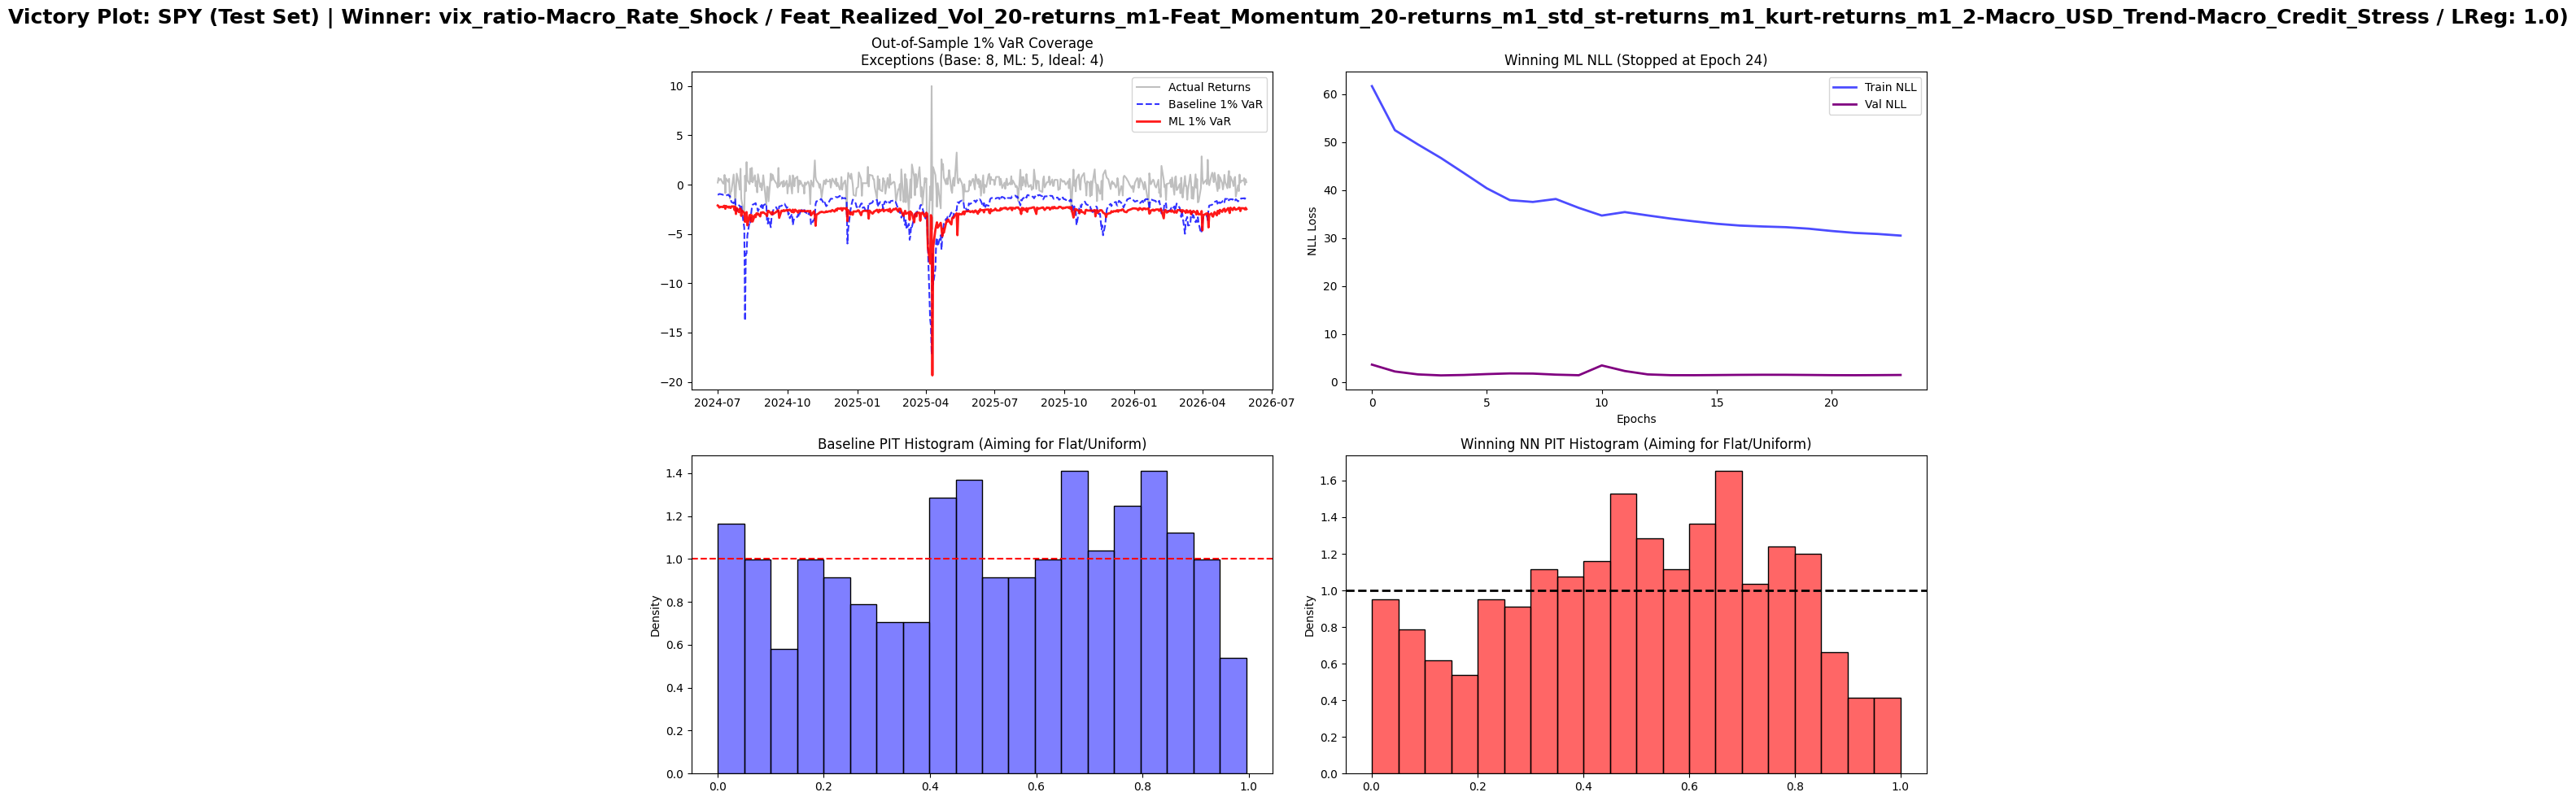


STATIC SPLIT SHOWDOWN & TUNING: TSLA
Fetching TSLA data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2869 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.7207, ks_stat: 0.0985
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.6624, ks_stat: 0.0543
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_

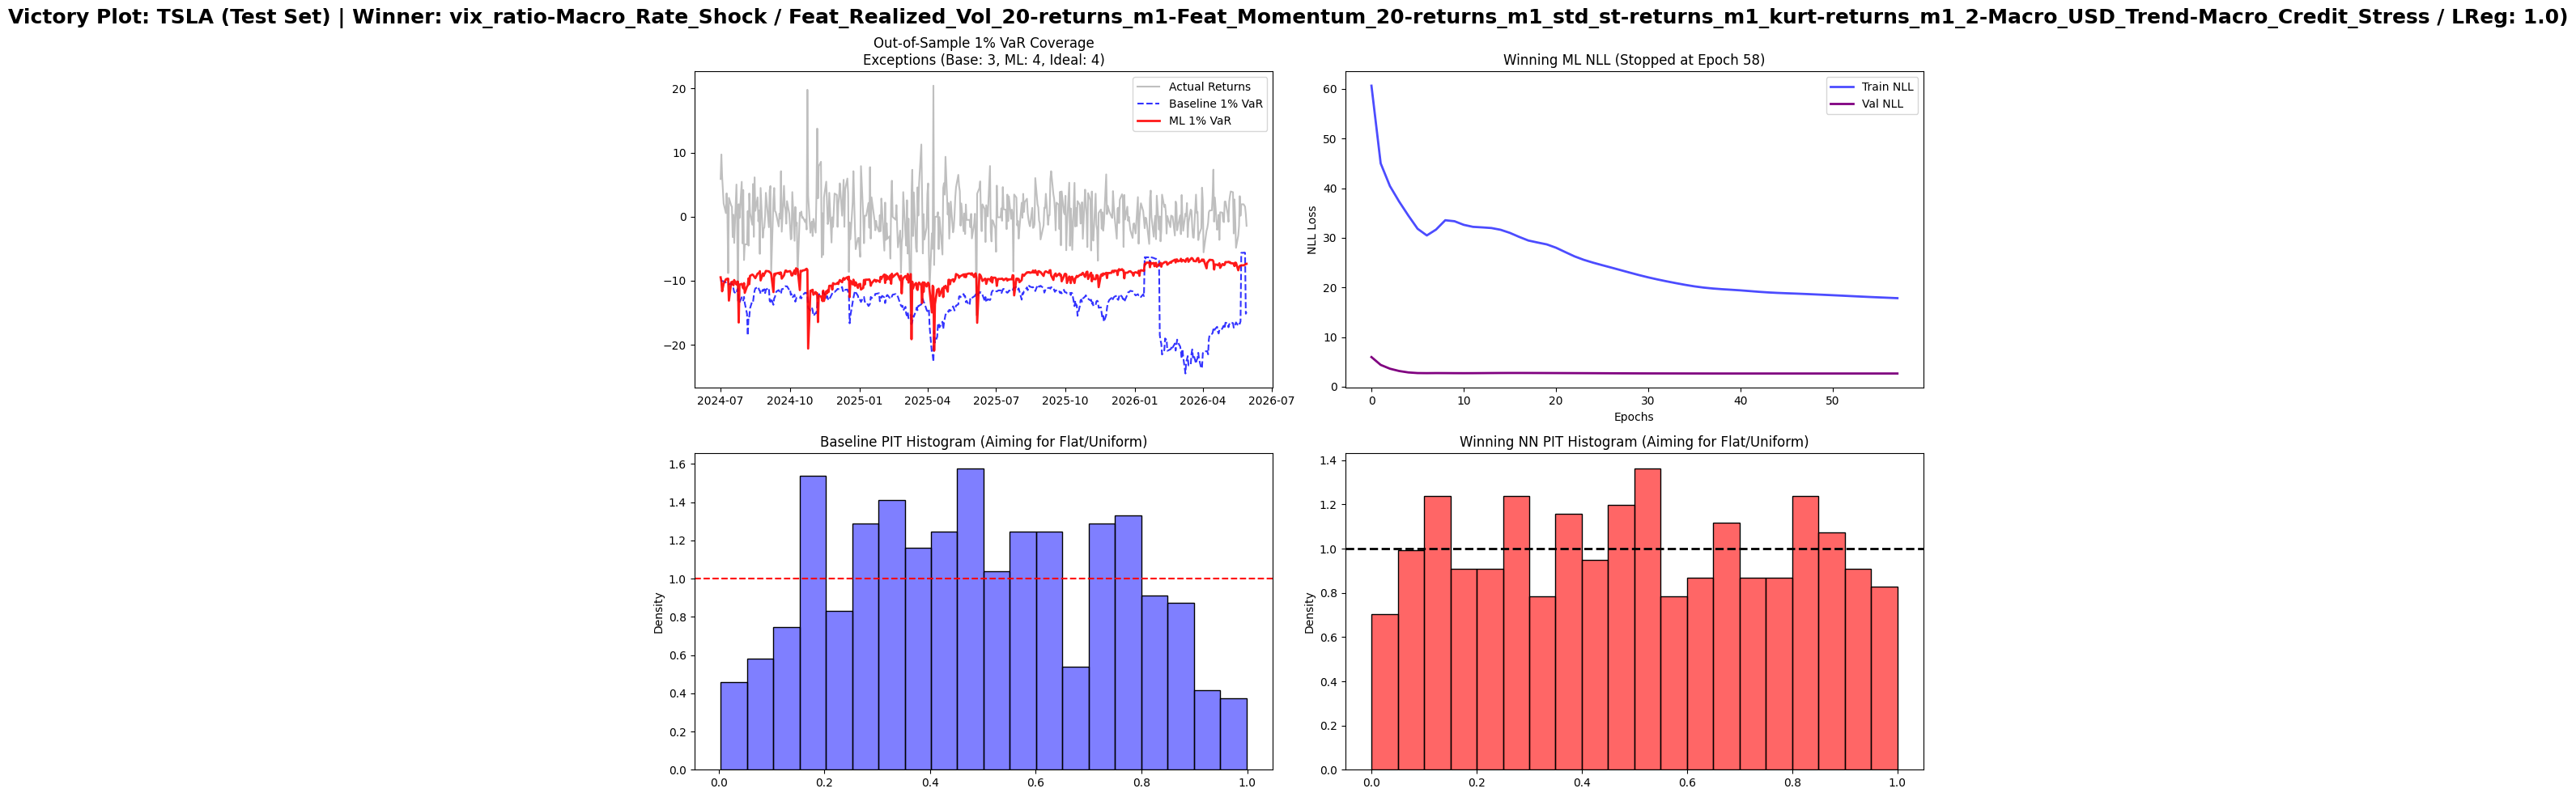


STATIC SPLIT SHOWDOWN & TUNING: QQQ
Fetching QQQ data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2910 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.7185, ks_stat: 0.0837
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.7167, ks_stat: 0.0759
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_st

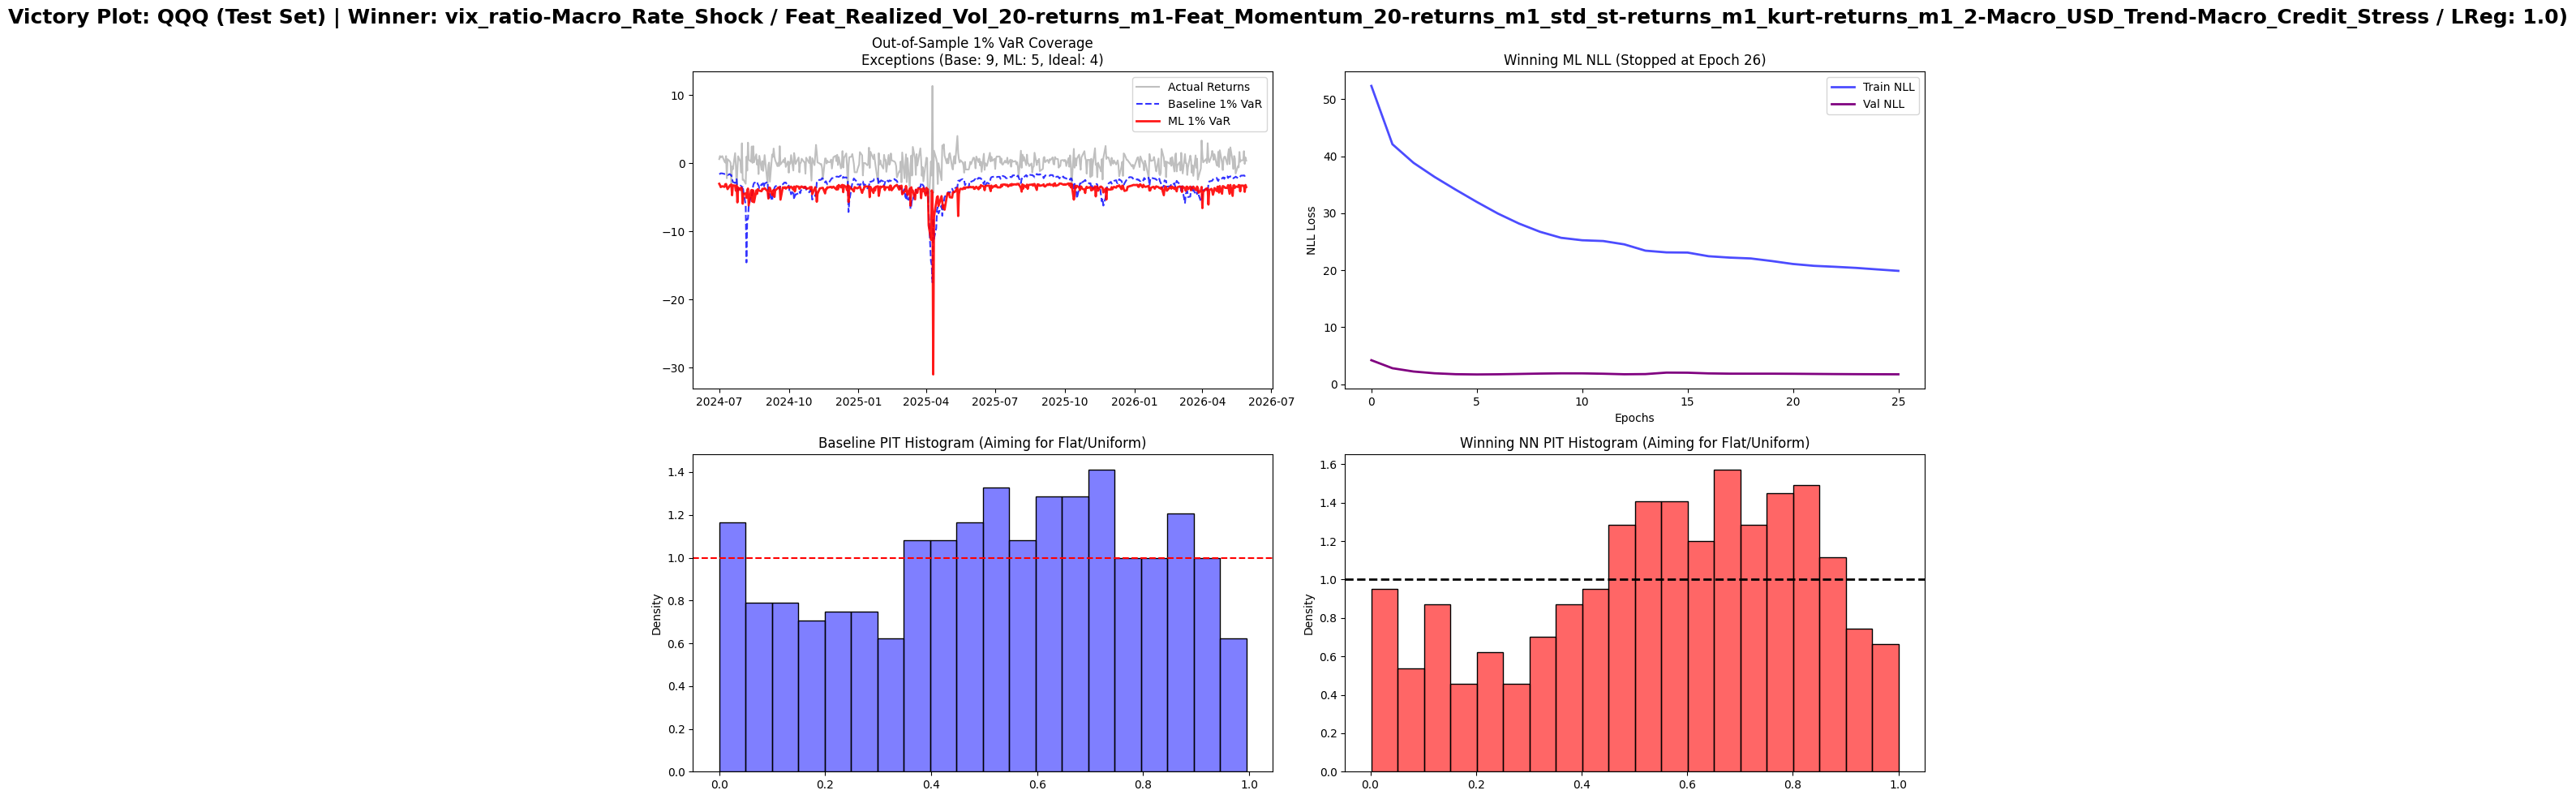


STATIC SPLIT SHOWDOWN & TUNING: XLF
Fetching XLF data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2910 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.5065, ks_stat: 0.0778
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 1.5099, ks_stat: 0.0641
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_st

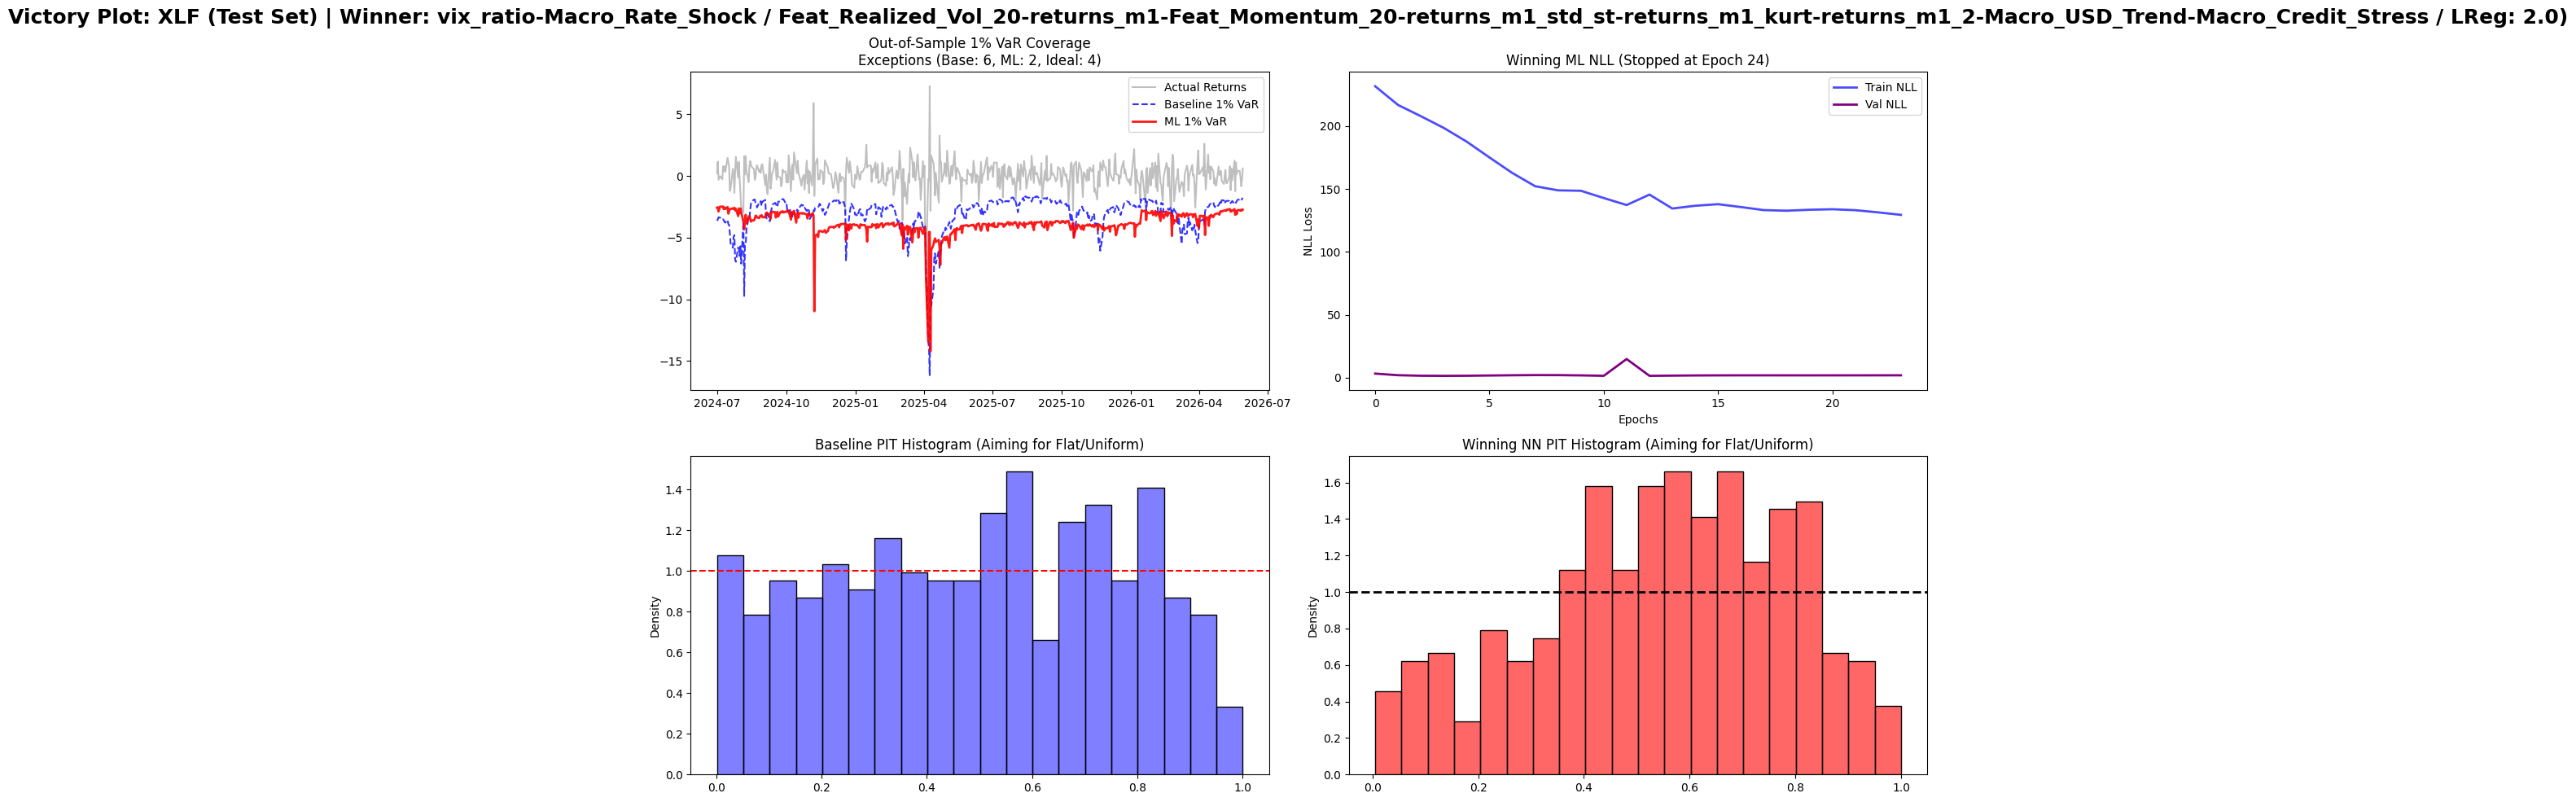


STATIC SPLIT SHOWDOWN & TUNING: NVDA
Fetching NVDA data...
Fetching VIX data...


[*********************100%***********************]  4 of 4 completed


Data Split -> Train: 2910 | Val: 504 | Test: 504

-> Running Neural Network Hyperparameter Grid
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 0.5)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%
          Achieved Best Val NLL: 2.6084, ks_stat: 0.0777
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_st-returns_m1_kurt-returns_m1_2-Macro_USD_Trend-Macro_Credit_Stress / LReg: 1.0)

--- INDEPENDENT BLOCK TEST SUMMARY (484-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 0
True Failure Rate:        0.0%
          Achieved Best Val NLL: 2.6041, ks_stat: 0.0494
   [Grid] Testing: vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol_20-returns_m1-Feat_Momentum_20-returns_m1_std_

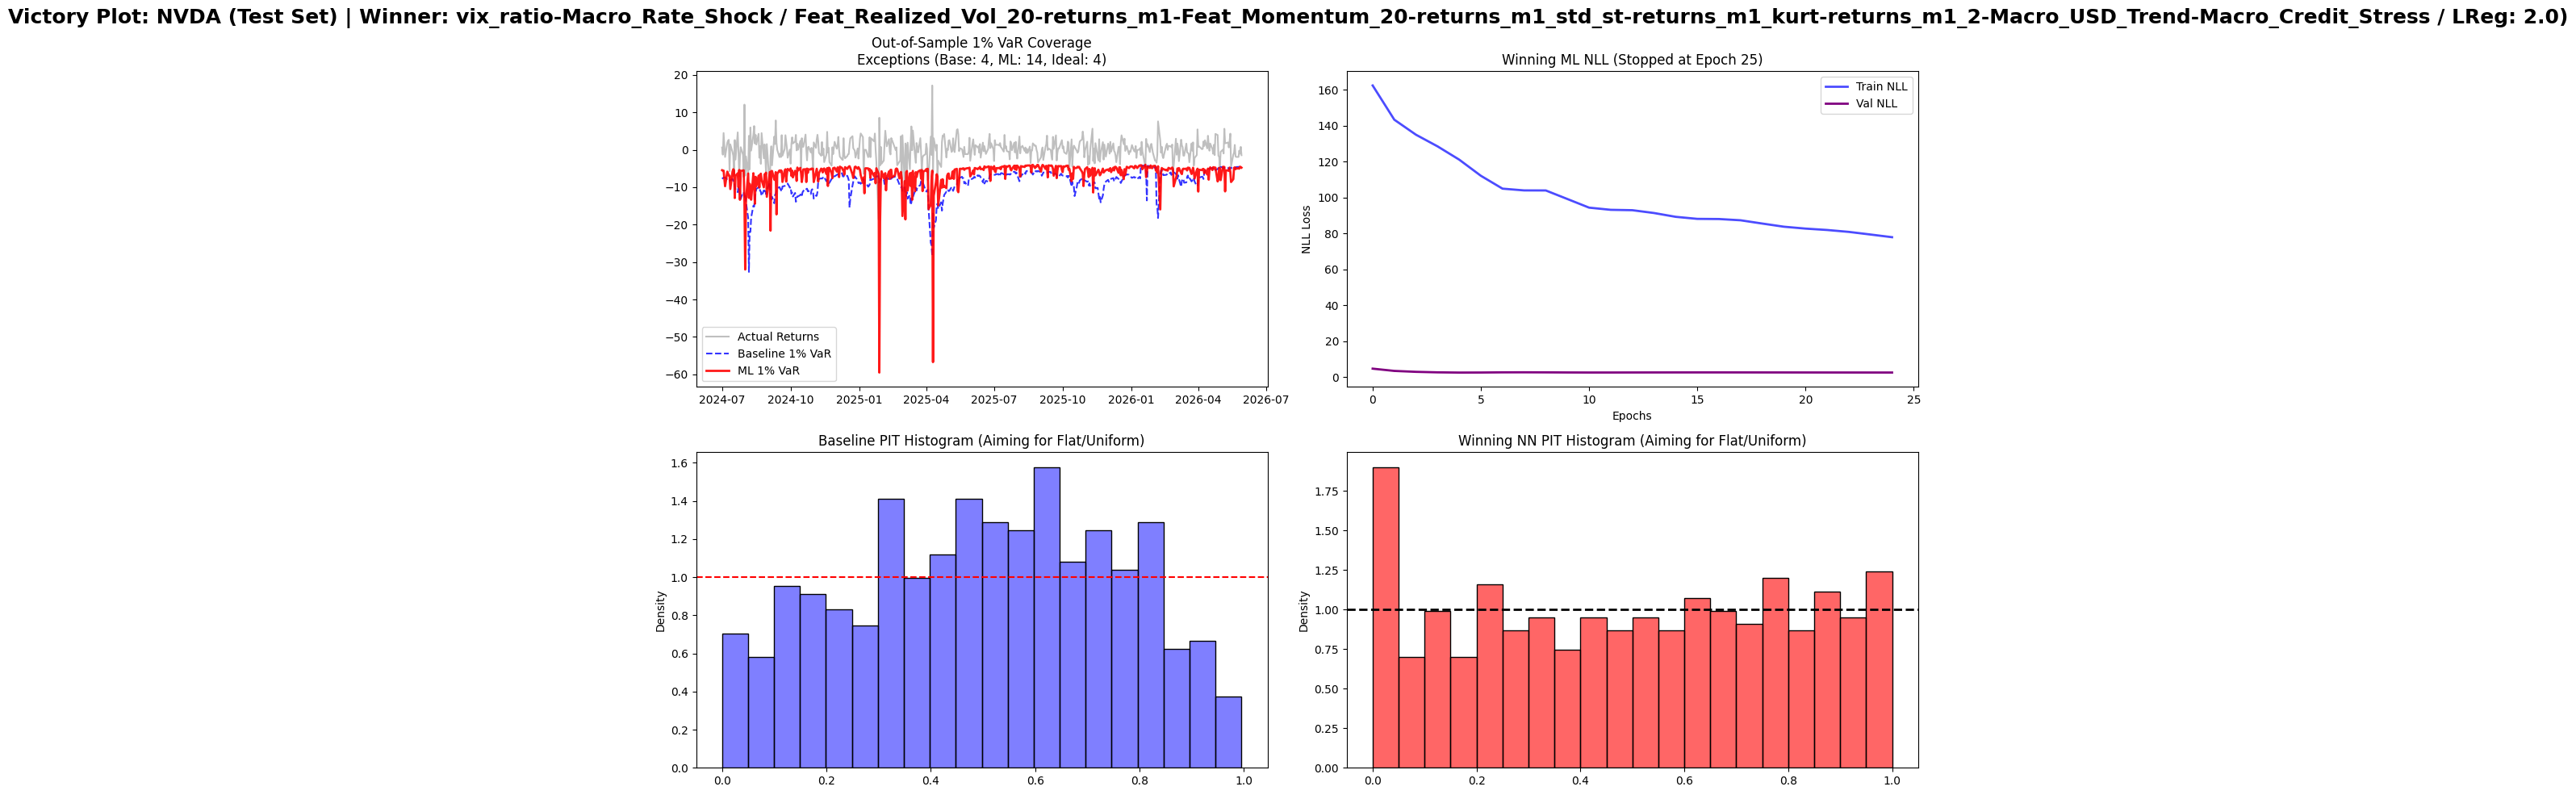

In [ ]:
table_results = []

for ticker in tickers:
    print(f"\n{'='*60}")
    print(f"STATIC SPLIT SHOWDOWN & TUNING: {ticker}")
    print(f"{'='*60}")
    
    # 1. Fetch Data
    df_features = read_data_features(ticker, start_date, end_date)
    
    if len(df_features) < MIN_DATA_ROWS:
        print(f"⚠️ Skipping {ticker}: Only {len(df_features)} days available. Need at least {MIN_DATA_ROWS} for robust splits.")
        continue
        
    # 2. Strict Chronological Split
    
    n_val = int(2 * 252)
    n_test = int(2 * 252)
    n_train = len(df_features) - n_test - n_val 

    # Use whatever is left for test, minimum 500
    n_test = len(df_features) - n_train - n_val 
    
    print(f"Data Split -> Train: {n_train} | Val: {n_val} | Test: {n_test}")
    
    y_train = df_features.iloc[:n_train]['returns']
    y_val = df_features.iloc[n_train:n_train+n_val]['returns']
    y_test = df_features.iloc[n_train+n_val:]['returns']

    df_train = df_features.iloc[:n_train]
    df_val = df_features.iloc[n_train:n_train+n_val]
    df_test = df_features.iloc[n_train+n_val:]
    
    # =========================================================
    # NEURAL NETWORK TUNING
    # =========================================================
    print("\n-> Running Neural Network Hyperparameter Grid")
    best_val_loss_overall = np.inf
    # best_val_loss_overall
    best_ks_stat = np.inf
    best_model_class = ""
    best_model_weights = None # Store the actual weights!
    best_config_name = ""

    best_model = None
    best_val_loss_history = []
    best_train_loss_history = []
    
    m_class = 'WideAndDeep'
    lr = 0.015
    # lr = 0.02

    # =========================================================
    # BASELINE MODEL
    # =========================================================
    # print("\n-> Running Baseline (VIX-Scaled Student-T)")
    # Extract Arrays for Baseline
    data_train = extract_array(df_train, y_train)
    data_val = extract_array(df_val, y_val)
    data_test = extract_array(df_test, y_test)

    optimal_beta = run_baseline(data_train, last_optimal_beta=0.5, cold_start=True)
    baseline_results = backtesting_baseline(data_test, optimal_beta)

    baseline_prior_v = backtesting_baseline(data_val, optimal_beta)
    # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
    prior_data_v = {'mu': baseline_prior_v['mu'][20:], 'sigma': baseline_prior_v['sigma'][20:], 'nu': baseline_prior_v['nu'][20:]}

    baseline_prior_train = backtesting_baseline(data_train, optimal_beta)
    # print(f"len(baseline_prior[mu]) {len(baseline_prior['mu'])}")
    prior_data_tr = {'mu': baseline_prior_train['mu'][20:], 'sigma': baseline_prior_train['sigma'][20:], 'nu': baseline_prior_train['nu'][20:]}

    # for m_class in grid_model_classes:
    for columns_deep in grid_columns_deep:
        for columns_linear in grid_columns_linear:
            for lambda_reg in grid_lambda_regs:
                
                config_name = f"{'-'.join(columns_deep)} / {'-'.join(columns_linear)} / LReg: {lambda_reg})"
                print(f"   [Grid] Testing: {config_name}")

                # Extract NN Tensors
                # columns_linear.append('vix_ratio_beta')
                # df_train['vix_ratio_beta'] = df_train['vix_ratio']** optimal_beta
                # df_val['vix_ratio_beta'] = df_val['vix_ratio']** optimal_beta
                # df_test['vix_ratio_beta'] = df_test['vix_ratio']** optimal_beta
                # X_lin_tr, X_deep_tr, y_tr = extract_df_nn(df_train, columns_linear, columns_deep)
                # X_lin_v, X_deep_v, y_v = extract_df_nn(df_val, columns_linear, columns_deep)
                # X_lin_te, X_deep_te, y_te = extract_df_nn(df_test, columns_linear, columns_deep)
                
                lookback_days = 20
                X_lin_tr, X_deep_tr, y_tr = create_cnn_sequences(df_train[columns_linear], df_train[columns_deep], df_train['returns'], lookback_days)
                X_lin_v, X_deep_v, y_v = create_cnn_sequences(df_val[columns_linear], df_val[columns_deep], df_val['returns'], lookback_days)
                X_lin_te, X_deep_te, y_te = create_cnn_sequences(df_test[columns_linear], df_test[columns_deep], df_test['returns'], lookback_days)

                # data_test = extract_array(df_test, y_te)
                # baseline_results = backtesting_baseline(data_test, optimal_beta)
                # print("\n-> Running Neural Networks")
                # model_class_to_use = 'conv'
                model_class_to_use = 'WideAndDeep'

                train_step, val_step, model = initializate_nn_model(columns_linear, model_class_to_use, lr, columns_deep=columns_deep, lambda_reg=lambda_reg)
                
                train_loss_history, val_loss_history = run_neural_networks(
                    X_lin_tr, X_deep_tr, y_tr,
                    X_lin_v, X_deep_v, y_v,
                    initial_epochs, train_step, val_step, model, prior_data_train=prior_data_tr, prior_data_v=prior_data_v, verbose=False
                )

                # Evaluate Winning Model on Test Set
                nn_val_results = backtesting_neural_networks(
                    tf.convert_to_tensor(X_lin_v, dtype=tf.float32), 
                    tf.convert_to_tensor(X_deep_v, dtype=tf.float32) if X_deep_v is not None else None, 
                    tf.convert_to_tensor(y_v, dtype=tf.float32), 
                    model
                )
                # nn_val_results = backtesting_neural_networks(
                #     tf.convert_to_tensor(X_lin_v.to_numpy(), dtype=tf.float32), 
                #     tf.convert_to_tensor(X_deep_v.to_numpy(), dtype=tf.float32) if X_deep_v is not None else None, 
                #     tf.convert_to_tensor(y_v.to_numpy(), dtype=tf.float32), 
                #     model
                # )
                
                # Calculate Validation KS Stat
                ks_stat = block_ks_test(pd.DataFrame(nn_val_results['pit_values']), block_size=len(pd.DataFrame(nn_val_results['pit_values'])), alpha=0.05)['KS_Stat'].values[0]
                ks_stat = ks_stat[0]
                min_val = min(val_loss_history)

                
                print(f"          Achieved Best Val NLL: {min_val:.4f}, ks_stat: {ks_stat:.4f}")
                # print(block_ks_test(pd.DataFrame(nn_results['pit_values']), block_size=len(pd.DataFrame(nn_results['pit_values'])), alpha=0.05))

                # if min_val < best_val_loss_overall:

                # if (ks_stat < best_ks_stat) and (min_val < best_val_loss_overall):
                if (min_val < best_val_loss_overall):

                # if (ks_stat < best_ks_stat):
                    best_ks_stat = ks_stat
                    best_val_loss_overall = min_val
                    
                    # SAVE THE WEIGHTS, not the model reference
                    best_model_class = model_class_to_use
                    best_model_weights = model.get_weights()

                    # best_model = model
                    best_config_name = config_name
                    best_val_loss_history = val_loss_history
                    best_train_loss_history = train_loss_history
                    best_columns_deep = columns_deep
                    best_columns_linear = columns_linear
                    
    print(f"\n🏆 WINNING CONFIGURATION: {best_config_name} with Val NLL = {best_val_loss_overall:.4f} and KS Stat: {best_ks_stat:.4f}")
    
    # Re-initialize a fresh model with the winning config (using best_model_class)
    _, _, best_model = initializate_nn_model(best_columns_linear, best_model_class, lr, columns_deep=best_columns_deep, 
                                             lambda_reg=float(best_config_name.split()[-1].strip(')')))

    # LOAD THE BEST WEIGHTS INTO IT
    best_model.set_weights(best_model_weights)

    # NOW evaluate on the Test Set using CNN sequences!
    X_lin_te_winning, X_deep_te_winning, y_te_winning = create_cnn_sequences(
        df_test[best_columns_linear], df_test[best_columns_deep], df_test['returns'], lookback_days
    )

    nn_results = backtesting_neural_networks(
        tf.convert_to_tensor(X_lin_te_winning, dtype=tf.float32), 
        tf.convert_to_tensor(X_deep_te_winning, dtype=tf.float32) if X_deep_te_winning is not None else None, 
        tf.convert_to_tensor(y_te_winning, dtype=tf.float32), 
        best_model
    )

    # Align baseline test results with the CNN lookback window
    baseline_results_aligned = {
        'pit_values': baseline_results['pit_values'][lookback_days:],
        'mu': baseline_results['mu'][lookback_days:],
        'sigma': baseline_results['sigma'][lookback_days:],
        'nu': baseline_results['nu'][lookback_days:]
    }

    y_te_aligned = df_test['returns'].iloc[lookback_days:]
    actual_returns = y_te_aligned.values

        # Re-extract the winning test features!
    # X_lin_te_winning, X_deep_te_winning, _ = extract_df_nn(df_test, best_columns_linear, best_columns_deep)

    # # Evaluate Winning Model on Test Set
    # nn_results = backtesting_neural_networks(
    #     tf.convert_to_tensor(X_lin_te_winning.to_numpy(), dtype=tf.float32), 
    #     tf.convert_to_tensor(X_deep_te_winning.to_numpy(), dtype=tf.float32) if X_deep_te_winning is not None else None, 
    #     tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
    #     best_model
    # )

    # # Evaluate Winning Model on Test Set
    # nn_results = backtesting_neural_networks(
    #     tf.convert_to_tensor(X_lin_te.to_numpy(), dtype=tf.float32), 
    #     tf.convert_to_tensor(X_deep_te.to_numpy(), dtype=tf.float32) if X_deep_te is not None else None, 
    #     tf.convert_to_tensor(y_te.to_numpy(), dtype=tf.float32), 
    #     best_model
    # )
    
    # =========================================================
    # METRICS EVALUATION
    # =========================================================
    # actual_returns = y_te.values
    actual_returns = y_te

    
    def calculate_metrics(results_dict):
        mu = results_dict['mu']
        sigma = results_dict['sigma']
        nu = results_dict['nu']
        pit = results_dict['pit_values']
        df_ks_pit = block_ks_test(pd.DataFrame(pit), block_size=len(pit), alpha=0.05)
        # ks_stat = df_ks['KS_Stat']
        
        pit_accept = df_ks_pit['Status'].values[0]

        # CRPS
        ensembles = generate_montecarlo(mu, sigma, nu, n_samples=1000)
        df_eval = evaluate_forecasts(y_te, ensembles)
        crps = df_eval['CRPS'].mean()
        nll = -df_eval['Log_Likelihood'].sum()
        
        # VaR 99% for Kupiec Test
        var_99 = t.ppf(0.01, df=nu, loc=mu, scale=sigma)
        # print('calculate metrics results')
        # print(len(actual_returns[actual_returns < var_99]), len(actual_returns))
        kupiec = kupiec_pof_test(actual_returns, var_99, confidence_level=0.99)
        # print(kupiec)
        # print('P_Value: ', kupiec['P_Value'])

        return crps, nll, kupiec, var_99, pit, df_ks_pit
    
    # Update calculate_metrics to use y_te_aligned internally
    def calculate_metrics_aligned(results_dict):
        mu = results_dict['mu']
        sigma = results_dict['sigma']
        nu = results_dict['nu']
        pit = results_dict['pit_values']
        df_ks_pit = block_ks_test(pd.DataFrame(pit), block_size=len(pit), alpha=0.05)
        
        pit_accept = df_ks_pit['Status'].values[0]

        # CRPS
        ensembles = generate_montecarlo(mu, sigma, nu, n_samples=1000)
        df_eval = evaluate_forecasts(y_te_aligned, ensembles)
        crps = df_eval['CRPS'].mean()
        nll = -df_eval['Log_Likelihood'].sum()
        
        # VaR 99% for Kupiec Test
        var_99 = t.ppf(0.01, df=nu, loc=mu, scale=sigma)
        kupiec = kupiec_pof_test(actual_returns, var_99, confidence_level=0.99)

        return crps, nll, kupiec, var_99, pit, df_ks_pit

    print('calculate metrics baseline')
    crps_base, nll_base, kupiec_base, var_base, pit_base, pit_ks_base = calculate_metrics_aligned(baseline_results_aligned)
    print('calculate metrics Neural-Network')
    crps_nn, nll_nn, kupiec_nn, var_nn, pit_nn, pit_ks_nn = calculate_metrics_aligned(nn_results)
    
    table_results.append({
        'Ticker': ticker,
        'Winning_NN_Config': best_config_name,
        'NLL_Baseline': nll_base,
        'NLL_ML': nll_nn,
        'CRPS_Baseline': crps_base,
        'CRPS_ML': crps_nn,
        'LR_Statistic_base': float(kupiec_base['LR_Statistic']),
        'LR_Statistic_ML': float(kupiec_nn['LR_Statistic']),
        'PIT_Statistic_base': float(pit_ks_base['KS_Stat'].iloc[0][0]),
        'PIT_Statistic_ML': float(pit_ks_nn['KS_Stat'].iloc[0][0]),

        'Exceptions_Base': f"{kupiec_base['Exceptions']} / {int(kupiec_base['Expected'])}",
        'Exceptions_ML': f"{kupiec_nn['Exceptions']} / {int(kupiec_nn['Expected'])}",
        'Kupiec_Base_Status': kupiec_base['Status'],
        'Kupiec_ML_Status': kupiec_nn['Status'],
        'KS_PIT_Base_Result': pit_ks_base['Status'].iloc[0][0],
        'KS_PIT_ML_Result': pit_ks_nn['Status'].iloc[0][0]
    })
    
    # =========================================================
    # VICTORY PLOTS
    # =========================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Victory Plot: {ticker} (Test Set) | Winner: {best_config_name}", fontsize=18, fontweight='bold')
    
    # Plot 1: 1% VaR Exceedance Coverage
    dates_test = df_test.index[lookback_days:]
    axes[0, 0].plot(dates_test, actual_returns, label='Actual Returns', color='gray', alpha=0.5)
    axes[0, 0].plot(dates_test, var_base, label='Baseline 1% VaR', color='blue', alpha=0.8, linestyle='--')
    axes[0, 0].plot(dates_test, var_nn, label='ML 1% VaR', color='red', alpha=0.9, linewidth=2)
    axes[0, 0].set_title(f"Out-of-Sample 1% VaR Coverage\nExceptions (Base: {kupiec_base['Exceptions']}, ML: {kupiec_nn['Exceptions']}, Ideal: {int(kupiec_nn['Expected'])})")
    axes[0, 0].legend()
    
    # Plot 2: Validation Loss Curve (Early Stopping)
    axes[0, 1].plot(best_train_loss_history, label='Train NLL', color='blue', alpha=0.7, linewidth=2)
    axes[0, 1].plot(best_val_loss_history, label='Val NLL', color='purple', linewidth=2)
    axes[0, 1].set_title(f"Winning ML NLL (Stopped at Epoch {len(best_val_loss_history)})")
    axes[0, 1].set_xlabel("Epochs")
    axes[0, 1].set_ylabel("NLL Loss")
    axes[0, 1].legend()
    
    # Plot 3: Baseline PIT Histogram
    sns.histplot(pit_base, bins=20, color='blue', alpha=0.5, stat='density', ax=axes[1, 0])
    axes[1, 0].axhline(1.0, color='red', linestyle='--')
    axes[1, 0].set_title("Baseline PIT Histogram (Aiming for Flat/Uniform)")
    
    # Plot 4: ML PIT Histogram
    sns.histplot(pit_nn, bins=20, color='red', alpha=0.6, stat='density', ax=axes[1, 1])
    axes[1, 1].axhline(1.0, color='black', linestyle='--', linewidth=2)
    axes[1, 1].set_title("Winning NN PIT Histogram (Aiming for Flat/Uniform)")
    
    plt.tight_layout()
    plt.show()


## 2. Quantitative Summary & Export

In [39]:
# import os
# df_res = pd.DataFrame(table_results)
# # df_res 
# df_res['Winner'] = 'Tie'
# df_res.loc[(df_res.PIT_Statistic_base > df_res.PIT_Statistic_base) & (df_res.LR_Statistic_base > df_res.LR_Statistic_ML), 'Winner'] = 'Baseline'
# df_res.loc[(df_res.PIT_Statistic_base < df_res.PIT_Statistic_base) & (df_res.LR_Statistic_base < df_res.LR_Statistic_ML), 'Winner'] = 'ML'
# df_res


In [40]:
import os
df_res = pd.DataFrame(table_results)
if len(df_res) > 0:
    df_res.set_index('Ticker', inplace=True)
    df_res['NLL_Winner'] = np.where(df_res['NLL_ML'] < df_res['NLL_Baseline'], 'ML', 'Baseline')
    df_res['CRPS_Winner'] = np.where(df_res['CRPS_ML'] < df_res['CRPS_Baseline'], 'ML', 'Baseline')
    df_res['Winner'] = 'Tie'
    df_res.loc[(df_res.PIT_Statistic_base < df_res.PIT_Statistic_ML) & (df_res.LR_Statistic_base < df_res.LR_Statistic_ML), 'Winner'] = 'Baseline'
    df_res.loc[(df_res.PIT_Statistic_base > df_res.PIT_Statistic_ML) & (df_res.LR_Statistic_base > df_res.LR_Statistic_ML), 'Winner'] = 'ML'
    display(df_res)
    
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    
    # Re-order and export
    export_cols = ['Winning_NN_Config', 'NLL_Baseline', 'NLL_ML', 'NLL_Winner', 
                   'CRPS_Baseline', 'CRPS_ML', 'CRPS_Winner', 
                   'Exceptions_Base', 'Exceptions_ML', 'Kupiec_Base_Status', 'Kupiec_ML_Status']
    
    df_export = df_res[export_cols]
    df_export.to_csv(f'{output_dir}/showdown_results_static.csv')
    df_export.to_json(f'{output_dir}/showdown_results_static.json', orient='index')
    
    print(f'Results successfully saved to {output_dir}')
else:
    print("No valid results to display.")


,Winning_NN_Config,NLL_Baseline,NLL_ML,CRPS_Baseline,CRPS_ML,LR_Statistic_base,LR_Statistic_ML,PIT_Statistic_base,PIT_Statistic_ML,Exceptions_Base,Exceptions_ML,Kupiec_Base_Status,Kupiec_ML_Status,KS_PIT_Base_Result,KS_PIT_ML_Result,NLL_Winner,CRPS_Winner,Winner
Ticker,,,,,,,,,,,,,,,,,,
ARKK,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,1133.399868,1152.750497,1.297758,1.453763,0.260947,0.817242,0.032758,0.068107,6 / 4,3 / 4,✅ PASSED,✅ PASSED,✅,❌,Baseline,Baseline,Baseline
USO,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,1069.017970,1076.537299,1.224121,1.277357,0.260947,2.881799,0.024883,0.032786,6 / 4,9 / 4,✅ PASSED,✅ PASSED,✅,✅,Baseline,Baseline,Baseline
SPY,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,602.735549,653.980330,0.431263,0.424391,1.741315,0.005285,0.059445,0.077195,8 / 4,5 / 4,✅ PASSED,✅ PASSED,✅,❌,Baseline,ML,Tie
TSLA,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,1342.708270,1327.008980,1.723050,1.853131,0.817242,0.156509,0.074948,0.028491,3 / 4,4 / 4,✅ PASSED,✅ PASSED,❌,✅,ML,Baseline,ML
QQQ,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,764.434615,794.089700,0.620572,0.795053,2.881799,0.005285,0.077842,0.139213,9 / 4,5 / 4,✅ PASSED,✅ PASSED,❌,❌,Baseline,Baseline,Tie
XLF,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,688.422620,739.031746,0.467230,0.694896,0.260947,2.161729,0.055682,0.145920,6 / 4,2 / 4,✅ PASSED,✅ PASSED,✅,❌,Baseline,Baseline,Baseline
NVDA,vix_ratio-Macro_Rate_Shock / Feat_Realized_Vol...,1207.106041,1216.551476,1.436245,1.433021,0.156509,11.596229,0.074003,0.047254,4 / 4,14 / 4,✅ PASSED,❌ FAILED,❌,✅,Baseline,ML,Tie


Results successfully saved to ../outputs
